Name: Sujal Shrestha

Student ID : 2357917


STEP 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


STEP 2: Import Libraries

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

STEP 3: Load Devnagari Dataset

In [13]:
data_path = "/content/drive/MyDrive/Ai/Dev/Dev/Train"

images = []

for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)

            try:
                img = Image.open(img_path).convert('L')  # grayscale
                img = img.resize((28, 28))              # resize like MNIST
                img = np.array(img) / 255.0             # normalize
                images.append(img)
            except:
                pass

images = np.array(images)

print("Dataset shape:", images.shape)

Dataset shape: (17000, 28, 28)


STEP 4: Reshape for CNN

In [23]:
images = images.reshape(-1, 28, 28, 1)

STEP 5: Train-Test Split

In [24]:
x_train, x_test = train_test_split(images, test_size=0.2, random_state=42)

STEP 6: Add Noise

In [16]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

STEP 7: Visualize Noisy vs Original

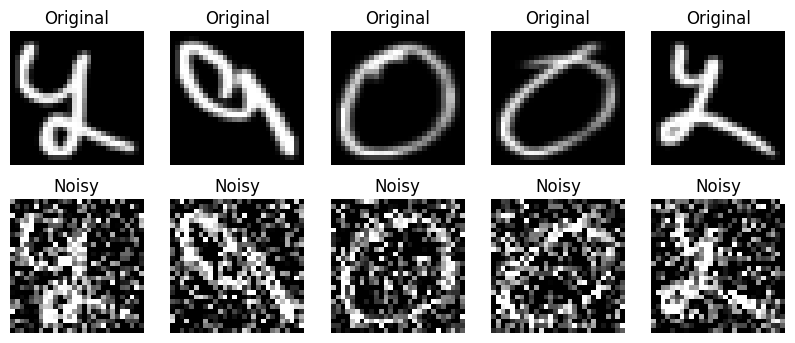

In [17]:
plt.figure(figsize=(10,4))

for i in range(5):
    # original
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # noisy
    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.show()

STEP 8: Build Autoencoder (4+ Layers as Required)

In [18]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

STEP 9: Train Model

In [19]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 57s 509ms/step - loss: 0.3287 - val_loss: 0.2262
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 81s 506ms/step - loss: 0.2132 - val_loss: 0.2049
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 50s 467ms/step - loss: 0.2033 - val_loss: 0.1992
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 474ms/step - loss: 0.1982 - val_loss: 0.1997
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 81s 460ms/step - loss: 0.1957 - val_loss: 0.1934
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 82s 462ms/step - loss: 0.1935 - val_loss: 0.1919
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 50s 470ms/step - loss: 0.1911 - val_loss: 0.1904
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 453ms/step - loss: 0.1898 - val_loss: 0.1889
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 50s 470ms/step - loss: 0.1882 - val_loss: 0.1875
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 481ms/step - loss: 0.1872 - val_loss: 0.1861


STEP 10: Denoise Images

In [20]:
denoised_images = autoencoder.predict(x_test_noisy)

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step


STEP 11: Visualize Results (FINAL OUTPUT)

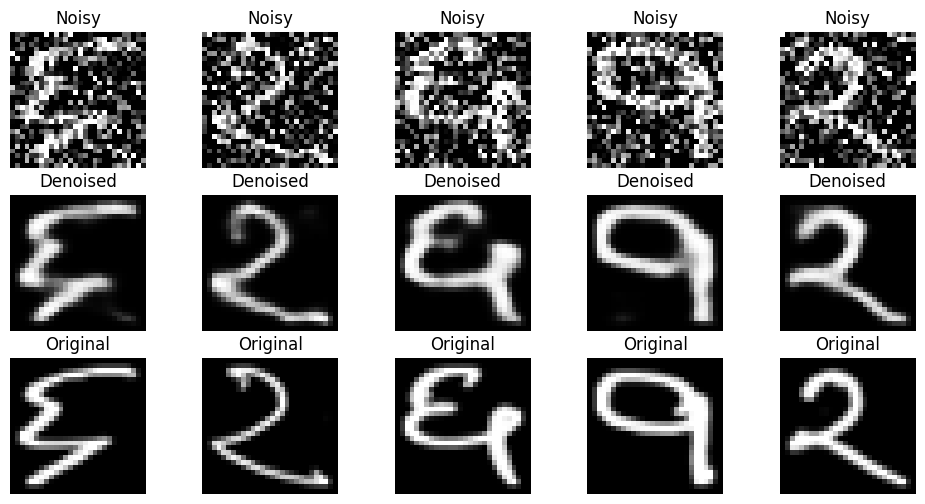

In [21]:
n = 5
plt.figure(figsize=(12,6))

for i in range(n):
    # noisy
    plt.subplot(3,n,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # denoised
    plt.subplot(3,n,i+1+n)
    plt.imshow(denoised_images[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # original
    plt.subplot(3,n,i+1+2*n)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

plt.show()

LOSS GRAPH

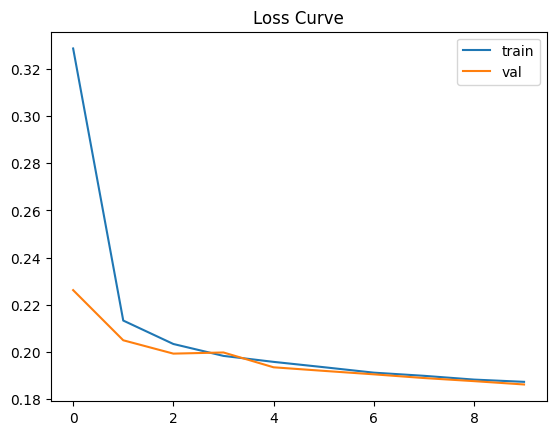

In [22]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss Curve")
plt.show()